In [1]:
import zipfile
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------
# Extract Dataset
# ----------------------------

zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/student")

# ----------------------------
# Load Dataset
# ----------------------------

df = pd.read_csv("/content/student/StudentPerformanceFactors.csv")

print(df.head())
print(df.info())

# ----------------------------
# Check Missing Values
# ----------------------------

print(df.isnull().sum())

# ----------------------------
# Target Variable
# ----------------------------

target = "Exam_Score"

X = df.drop(target, axis=1)
y = df[target]

# ----------------------------
# Numerical & Categorical Columns
# ----------------------------

num_cols = X.select_dtypes(include=["int64","float64"]).columns

cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# ----------------------------
# Preprocessing
# ----------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# ----------------------------
# Train Test Split
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ----------------------------
# Transform Data
# ----------------------------

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# ----------------------------
# Train Model
# ----------------------------

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# Prediction
# ----------------------------

y_pred = model.predict(X_test)

# ----------------------------
# Evaluation
# ----------------------------

print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

# ----------------------------
# Save Model
# ----------------------------

joblib.dump(model, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model Saved Successfully")

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [2]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    max_error
)
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

print("Model Evaluation")
print("-"*40)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance Score: {evs:.4f}")
print(f"Maximum Error: {max_err:.4f}")

Model Evaluation
----------------------------------------
Mean Absolute Error (MAE): 1.0730
Mean Squared Error (MSE): 4.6202
Root Mean Squared Error (RMSE): 2.1495
R² Score: 0.6731
Explained Variance Score: 0.6745
Maximum Error: 26.4500


In [3]:
results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

print(results.head(10))

   Actual Score  Predicted Score
0            65           64.705
1            65           66.360
2            71           70.255
3            64           65.770
4            66           66.285
5            66           66.635
6            72           71.030
7            66           66.865
8            70           69.655
9            70           70.060


In [4]:
results["Error"] = results["Actual Score"] - results["Predicted Score"]

print(results.head(10))

   Actual Score  Predicted Score  Error
0            65           64.705  0.295
1            65           66.360 -1.360
2            71           70.255  0.745
3            64           65.770 -1.770
4            66           66.285 -0.285
5            66           66.635 -0.635
6            72           71.030  0.970
7            66           66.865 -0.865
8            70           69.655  0.345
9            70           70.060 -0.060


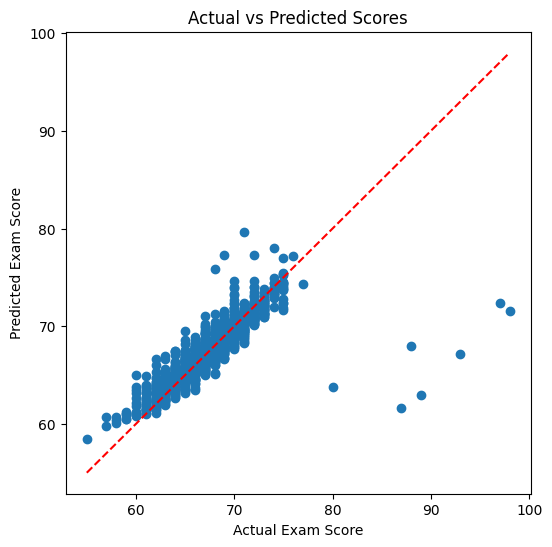

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Scores")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

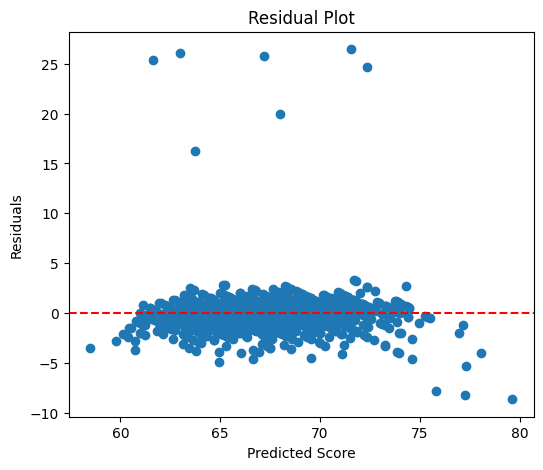

In [6]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [7]:
feature_names = preprocessor.get_feature_names_out()

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                                       Feature  Importance
1                              num__Attendance    0.374594
0                           num__Hours_Studied    0.240574
3                         num__Previous_Scores    0.085019
4                       num__Tutoring_Sessions    0.033134
5                       num__Physical_Activity    0.024561
2                             num__Sleep_Hours    0.024064
9                cat__Access_to_Resources_High    0.019144
6               cat__Parental_Involvement_High    0.018028
7                cat__Parental_Involvement_Low    0.014129
10                cat__Access_to_Resources_Low    0.011329
19                     cat__Family_Income_High    0.010759
34  cat__Parental_Education_Level_Postgraduate    0.009164
35                 cat__Distance_from_Home_Far    0.007938
29                cat__Peer_Influence_Positive    0.007731
33   cat__Parental_Education_Level_High School    0.007119


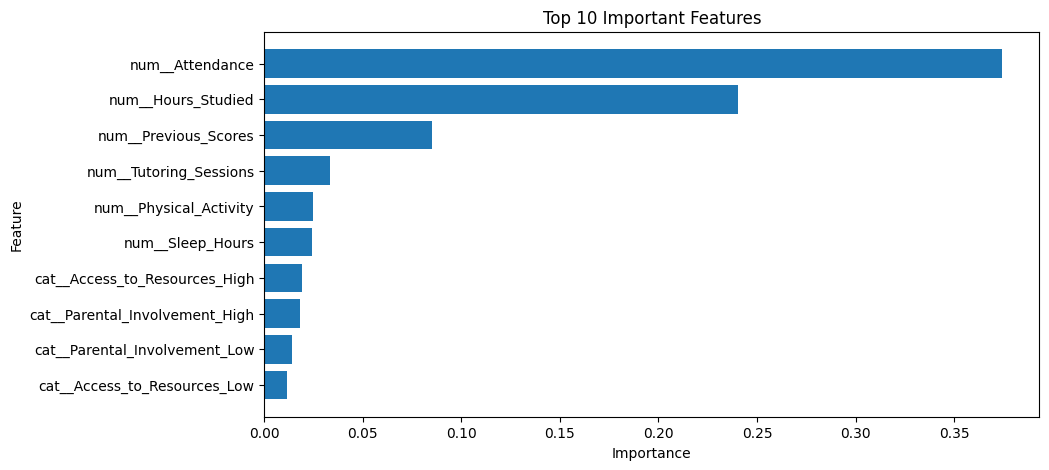

In [8]:
top = importance_df.head(10)

plt.figure(figsize=(10,5))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()